In [8]:
# ENTER ABSOLUTE PATH TO LOG DIRECTORY HERE
log_dir = "/home/ga53voq/master_thesis/logs/cave_exploration-continue-2025-08-21_11-20-16-2025-08-21_17-19-50/render_session_20250821_195859/episode_01"

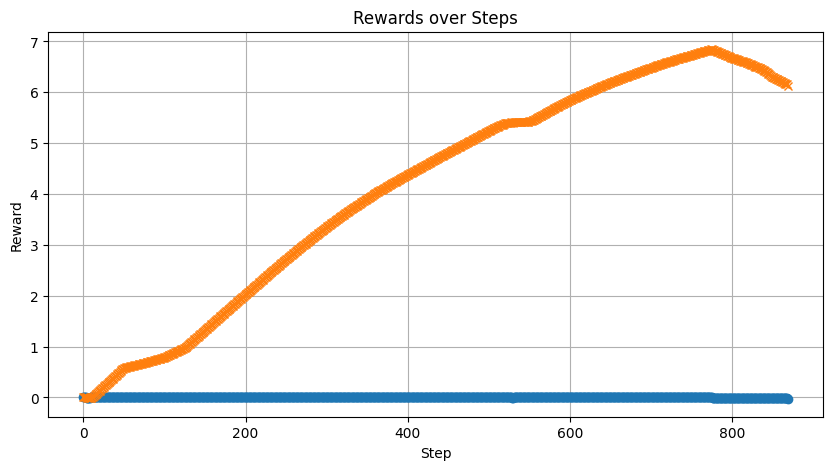

In [9]:
# Import necessary libraries
import os
import json
import matplotlib.pyplot as plt

#exec_dir = os.path.dirname(os.path.abspath(__file__))
#log_dir = os.path.join(exec_dir, log_dir)
if not os.path.exists(log_dir):
    print(f'Log directory does not exist: {log_dir}')
    exit(1)
detailed_files = [f for f in os.listdir(log_dir) if f.startswith('detailed_logs')]
rewards_file = detailed_files[0] if detailed_files else None
if rewards_file is None:
    print('No detailed_logs file found in the specified log directory.')
    exit(1)
rewards_file = os.path.join(log_dir, rewards_file)

# Load rewards from the JSON array log file
rewards = []

with open(rewards_file, 'r') as f:
    try:
        data = json.load(f)  # Expecting a list of dicts
        rewards = [entry.get('reward', 0.0) for entry in data]
        cumulative_rewards = [entry.get('cumulative_reward', 0.0) for entry in data]
    except Exception as e:
        print(f'Error loading JSON: {e}')


# Plot rewards over steps
if rewards:
    plt.figure(figsize=(10, 5))
    plt.plot(rewards, marker='o')
    plt.plot(cumulative_rewards, marker='x', linestyle='--', label='Cumulative Rewards')
    plt.title('Rewards over Steps')
    plt.xlabel('Step')
    plt.ylabel('Reward')
    plt.grid(True)
    plt.show()
else:
    print('No rewards found to plot.')

# Lidar directional data

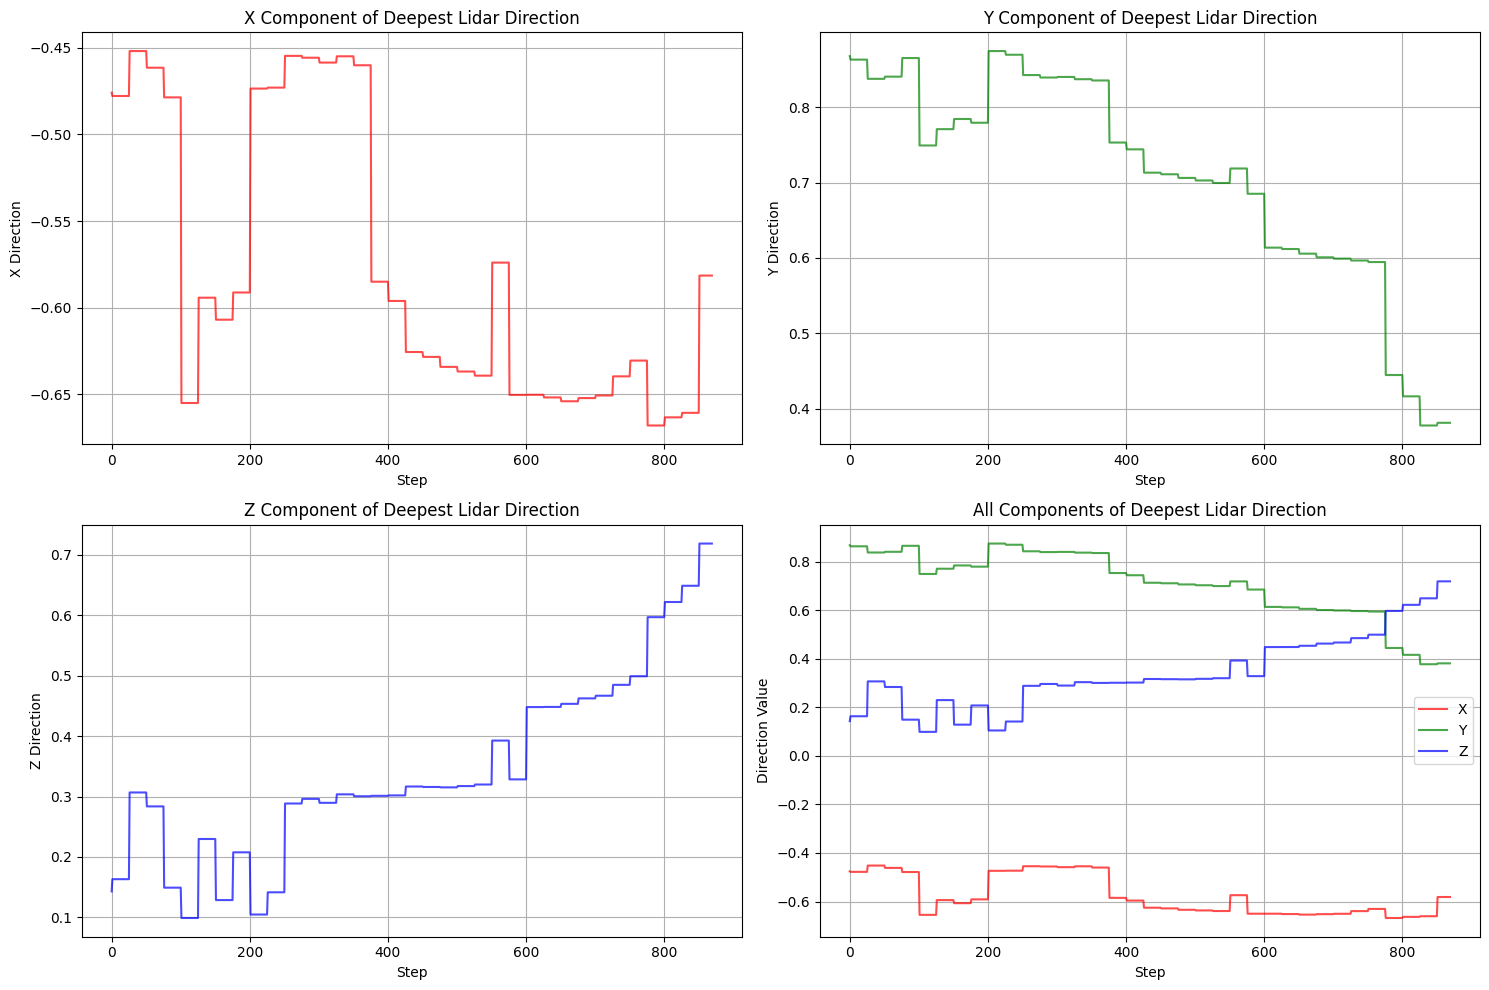

Total data points: 870
X component range: [-0.668, -0.452]
Y component range: [0.377, 0.875]
Z component range: [0.099, 0.719]


In [10]:
import numpy as np

# Extract deepest_lidar_direction data from the loaded data
lidar_directions = []
steps = []

for entry in data:
    if 'info' in entry and 'deepest_lidar_direction' in entry['info']:
        lidar_dir = entry['info']['deepest_lidar_direction']
        lidar_directions.append(lidar_dir)
        steps.append(entry['step'])

# Convert to numpy arrays for easier manipulation
lidar_directions = np.array(lidar_directions)

# Plot the lidar direction components over time
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot individual components
axes[0, 0].plot(steps, lidar_directions[:, 0], 'r-', alpha=0.7)
axes[0, 0].set_title('X Component of Deepest Lidar Direction')
axes[0, 0].set_xlabel('Step')
axes[0, 0].set_ylabel('X Direction')
axes[0, 0].grid(True)

axes[0, 1].plot(steps, lidar_directions[:, 1], 'g-', alpha=0.7)
axes[0, 1].set_title('Y Component of Deepest Lidar Direction')
axes[0, 1].set_xlabel('Step')
axes[0, 1].set_ylabel('Y Direction')
axes[0, 1].grid(True)

axes[1, 0].plot(steps, lidar_directions[:, 2], 'b-', alpha=0.7)
axes[1, 0].set_title('Z Component of Deepest Lidar Direction')
axes[1, 0].set_xlabel('Step')
axes[1, 0].set_ylabel('Z Direction')
axes[1, 0].grid(True)

# Plot all components together
axes[1, 1].plot(steps, lidar_directions[:, 0], 'r-', alpha=0.7, label='X')
axes[1, 1].plot(steps, lidar_directions[:, 1], 'g-', alpha=0.7, label='Y')
axes[1, 1].plot(steps, lidar_directions[:, 2], 'b-', alpha=0.7, label='Z')
axes[1, 1].set_title('All Components of Deepest Lidar Direction')
axes[1, 1].set_xlabel('Step')
axes[1, 1].set_ylabel('Direction Value')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

# Print some statistics
print(f"Total data points: {len(lidar_directions)}")
print(f"X component range: [{np.min(lidar_directions[:, 0]):.3f}, {np.max(lidar_directions[:, 0]):.3f}]")
print(f"Y component range: [{np.min(lidar_directions[:, 1]):.3f}, {np.max(lidar_directions[:, 1]):.3f}]")
print(f"Z component range: [{np.min(lidar_directions[:, 2]):.3f}, {np.max(lidar_directions[:, 2]):.3f}]")

# Rewards over time

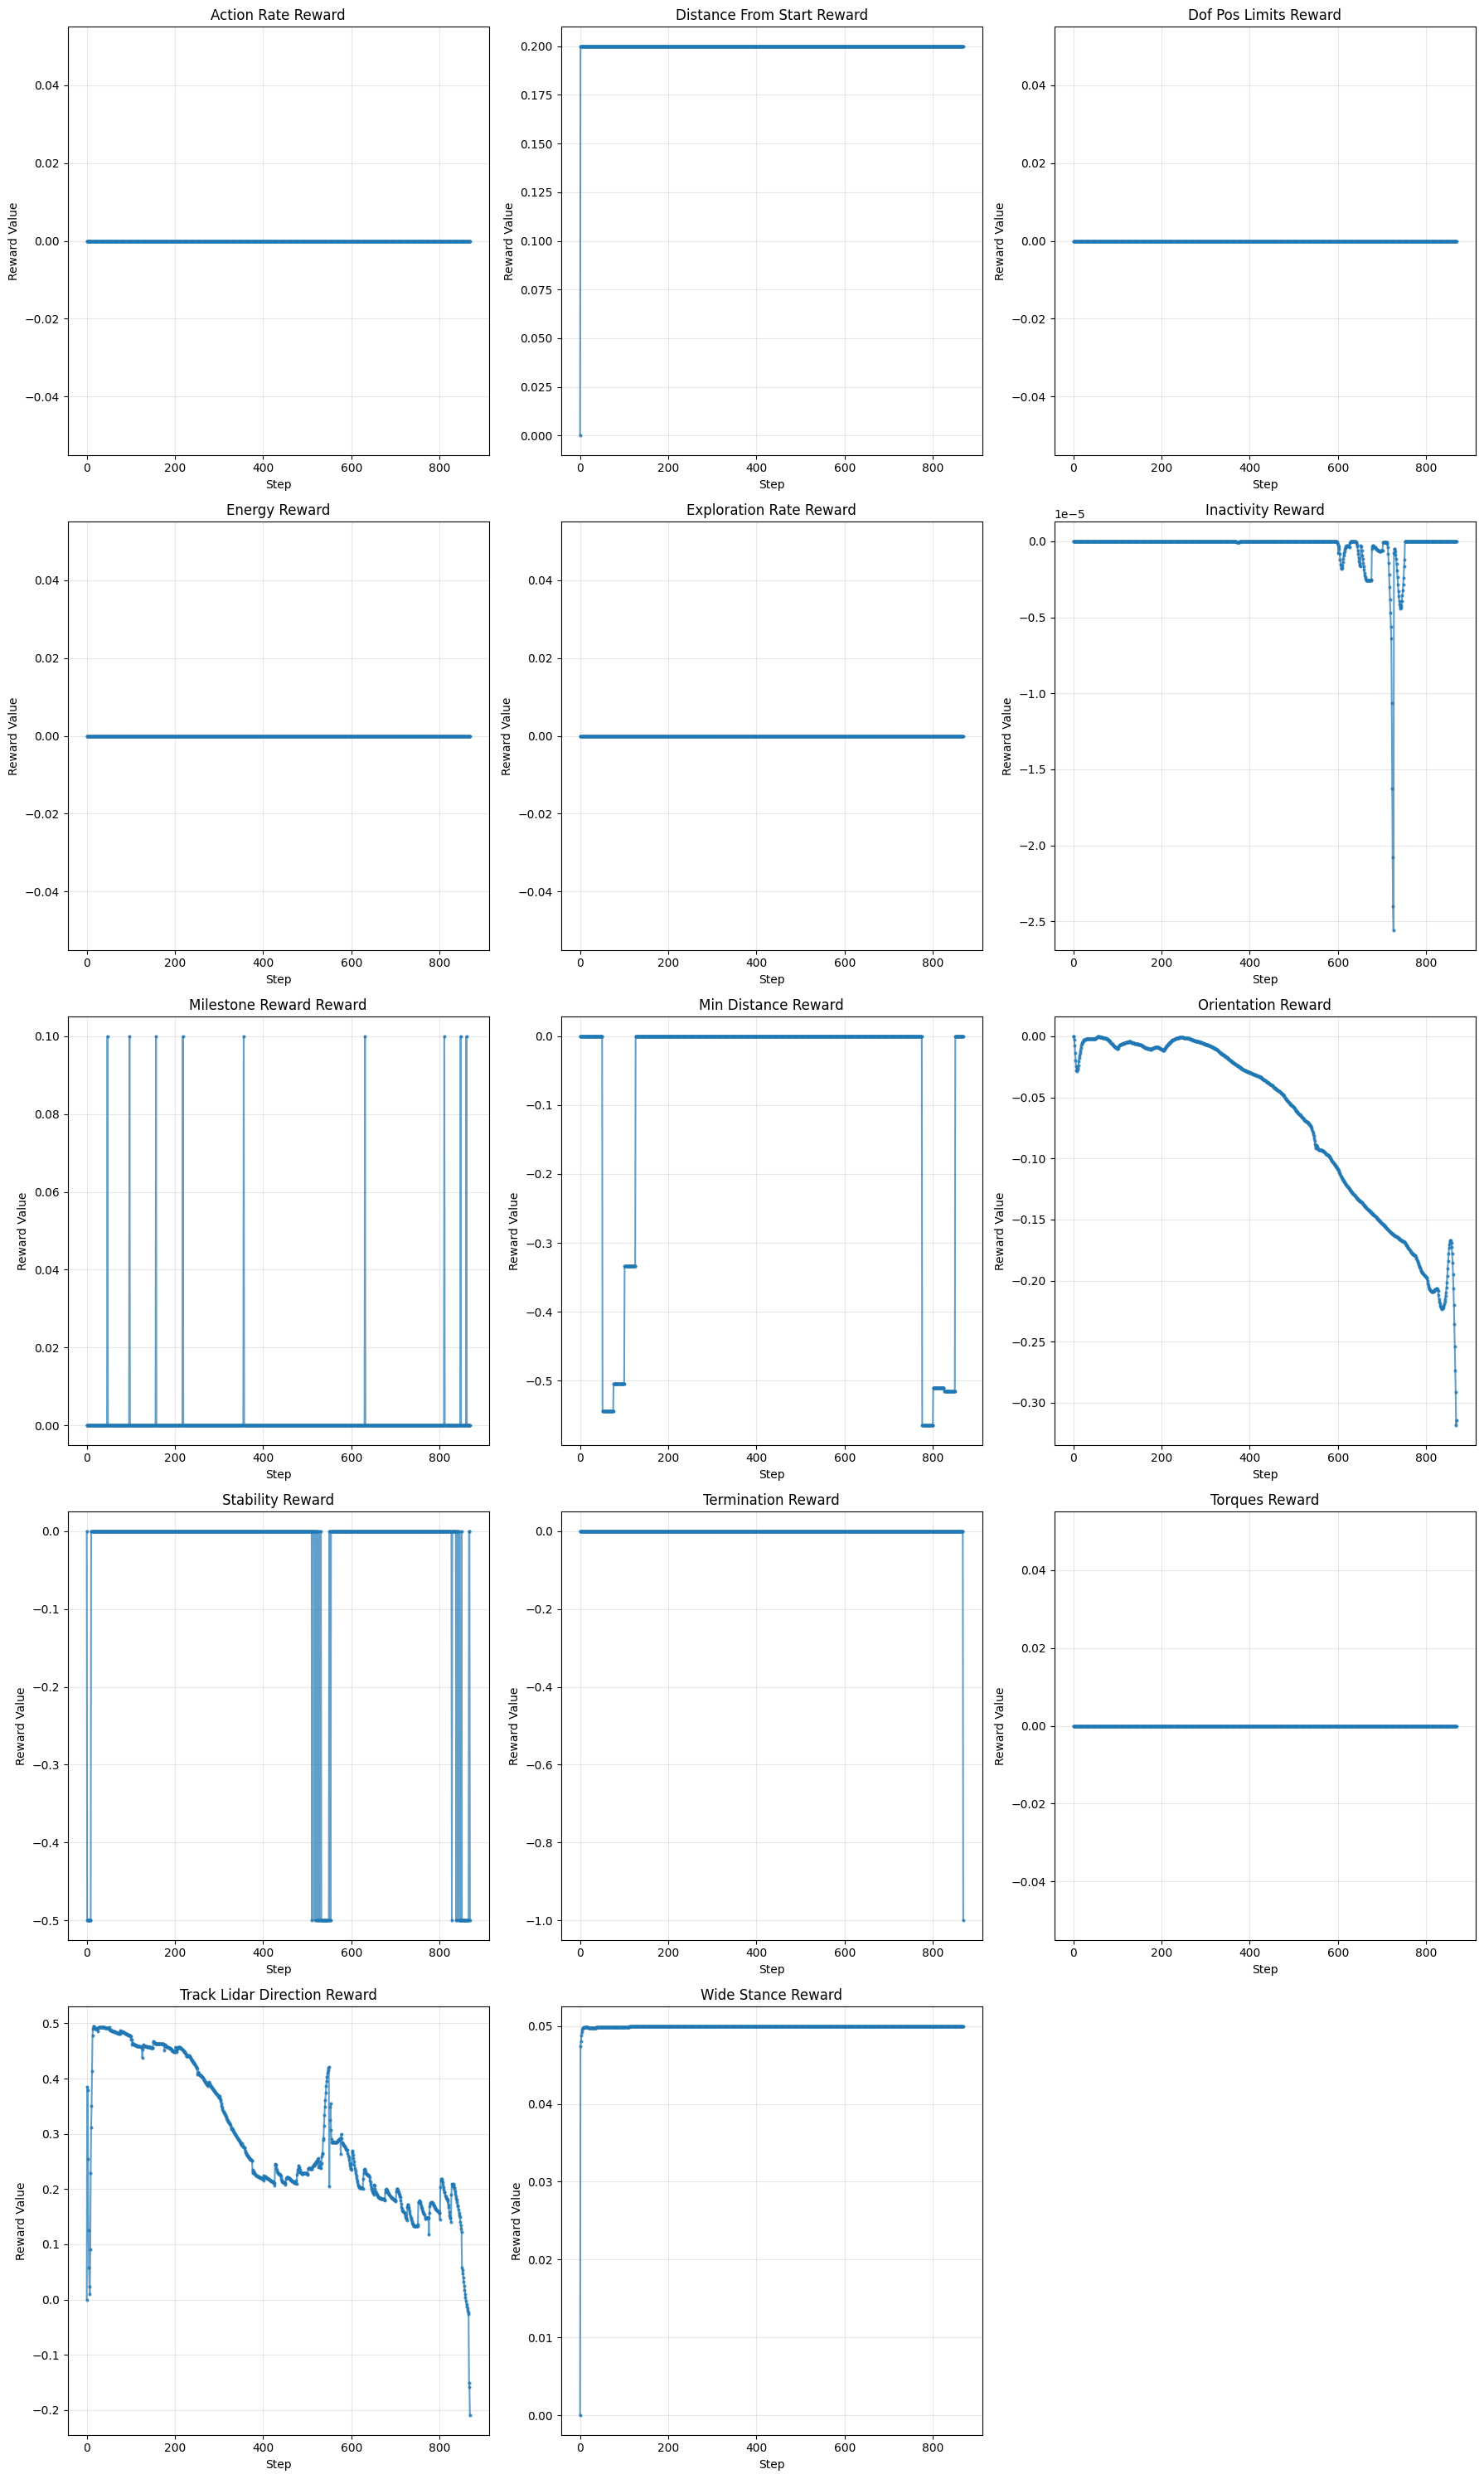

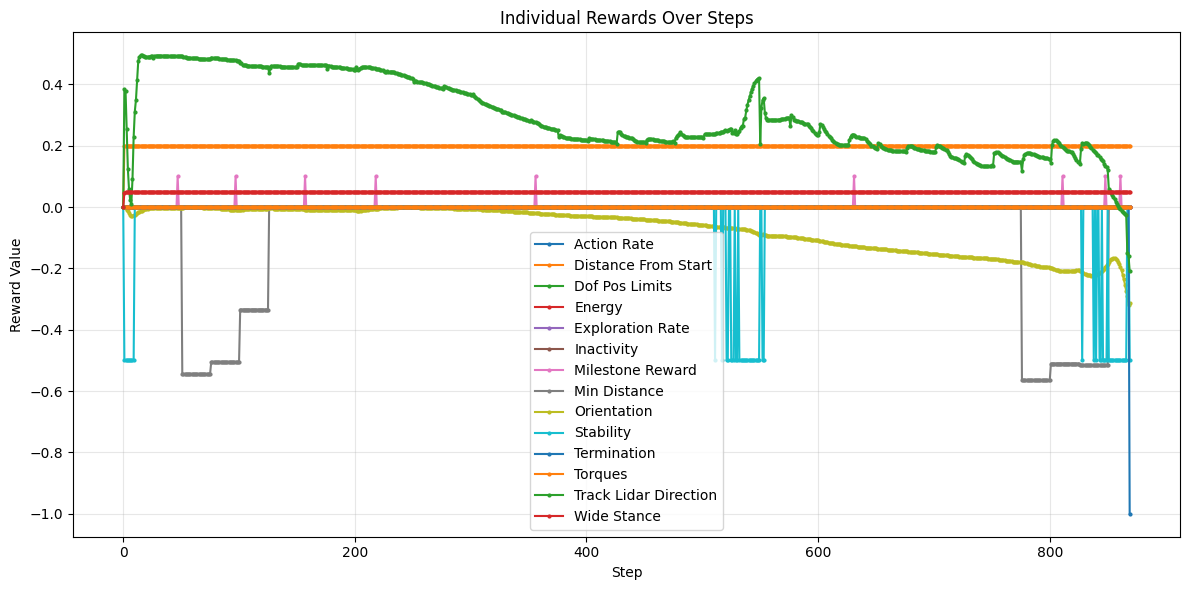

Individual Reward Statistics:
--------------------------------------------------
action_rate         : mean=  0.0000, std=  0.0000, min=  0.0000, max=  0.0000
distance_from_start : mean=  0.1998, std=  0.0068, min=  0.0000, max=  0.2000
dof_pos_limits      : mean=  0.0000, std=  0.0000, min=  0.0000, max=  0.0000
energy              : mean=  0.0000, std=  0.0000, min=  0.0000, max=  0.0000
exploration_rate    : mean=  0.0000, std=  0.0000, min=  0.0000, max=  0.0000
inactivity          : mean= -0.0000, std=  0.0000, min= -0.0000, max= -0.0000
milestone_reward    : mean=  0.0010, std=  0.0101, min=  0.0000, max=  0.1000
min_distance        : mean= -0.0854, std=  0.1898, min= -0.5651, max= -0.0000
orientation         : mean= -0.0704, std=  0.0723, min= -0.3185, max=  0.0000
stability           : mean= -0.0368, std=  0.1305, min= -0.5000, max= -0.0000
termination         : mean= -0.0011, std=  0.0339, min= -1.0000, max= -0.0000
torques             : mean=  0.0000, std=  0.0000, min=  0.00

In [11]:
# Extract individual rewards data
individual_rewards_data = {}
reward_steps = []

for entry in data:
    if 'individual_rewards' in entry:
        step = entry['step']
        reward_steps.append(step)
        
        for reward_name, reward_value in entry['individual_rewards'].items():
            if reward_name not in individual_rewards_data:
                individual_rewards_data[reward_name] = []
            individual_rewards_data[reward_name].append(reward_value)

# Create subplots for all individual rewards
reward_names = list(individual_rewards_data.keys())
num_rewards = len(reward_names)

# Calculate grid dimensions
cols = 3
rows = (num_rewards + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, 6 * rows))
axes = axes.flatten() if num_rewards > 1 else [axes]

# Plot each individual reward
for i, reward_name in enumerate(reward_names):
    axes[i].plot(reward_steps, individual_rewards_data[reward_name], marker='o', markersize=2, alpha=0.7)
    axes[i].set_title(f'{reward_name.replace("_", " ").title()} Reward')
    axes[i].set_xlabel('Step')
    axes[i].set_ylabel('Reward Value')
    axes[i].grid(True, alpha=0.3)

# Hide unused subplots
for i in range(num_rewards, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

# Print all reward graphs in a single figure
plt.figure(figsize=(12, 6))
for reward_name, values in individual_rewards_data.items():
    plt.plot(reward_steps, values, marker='o', markersize=2, label=reward_name.replace('_', ' ').title())
plt.title('Individual Rewards Over Steps')
plt.xlabel('Step')
plt.ylabel('Reward Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print statistics for each reward component
print("Individual Reward Statistics:")
print("-" * 50)
for reward_name, values in individual_rewards_data.items():
    values = np.array(values)
    print(f"{reward_name:20s}: mean={np.mean(values):8.4f}, std={np.std(values):8.4f}, min={np.min(values):8.4f}, max={np.max(values):8.4f}")

# Analyze action outputs

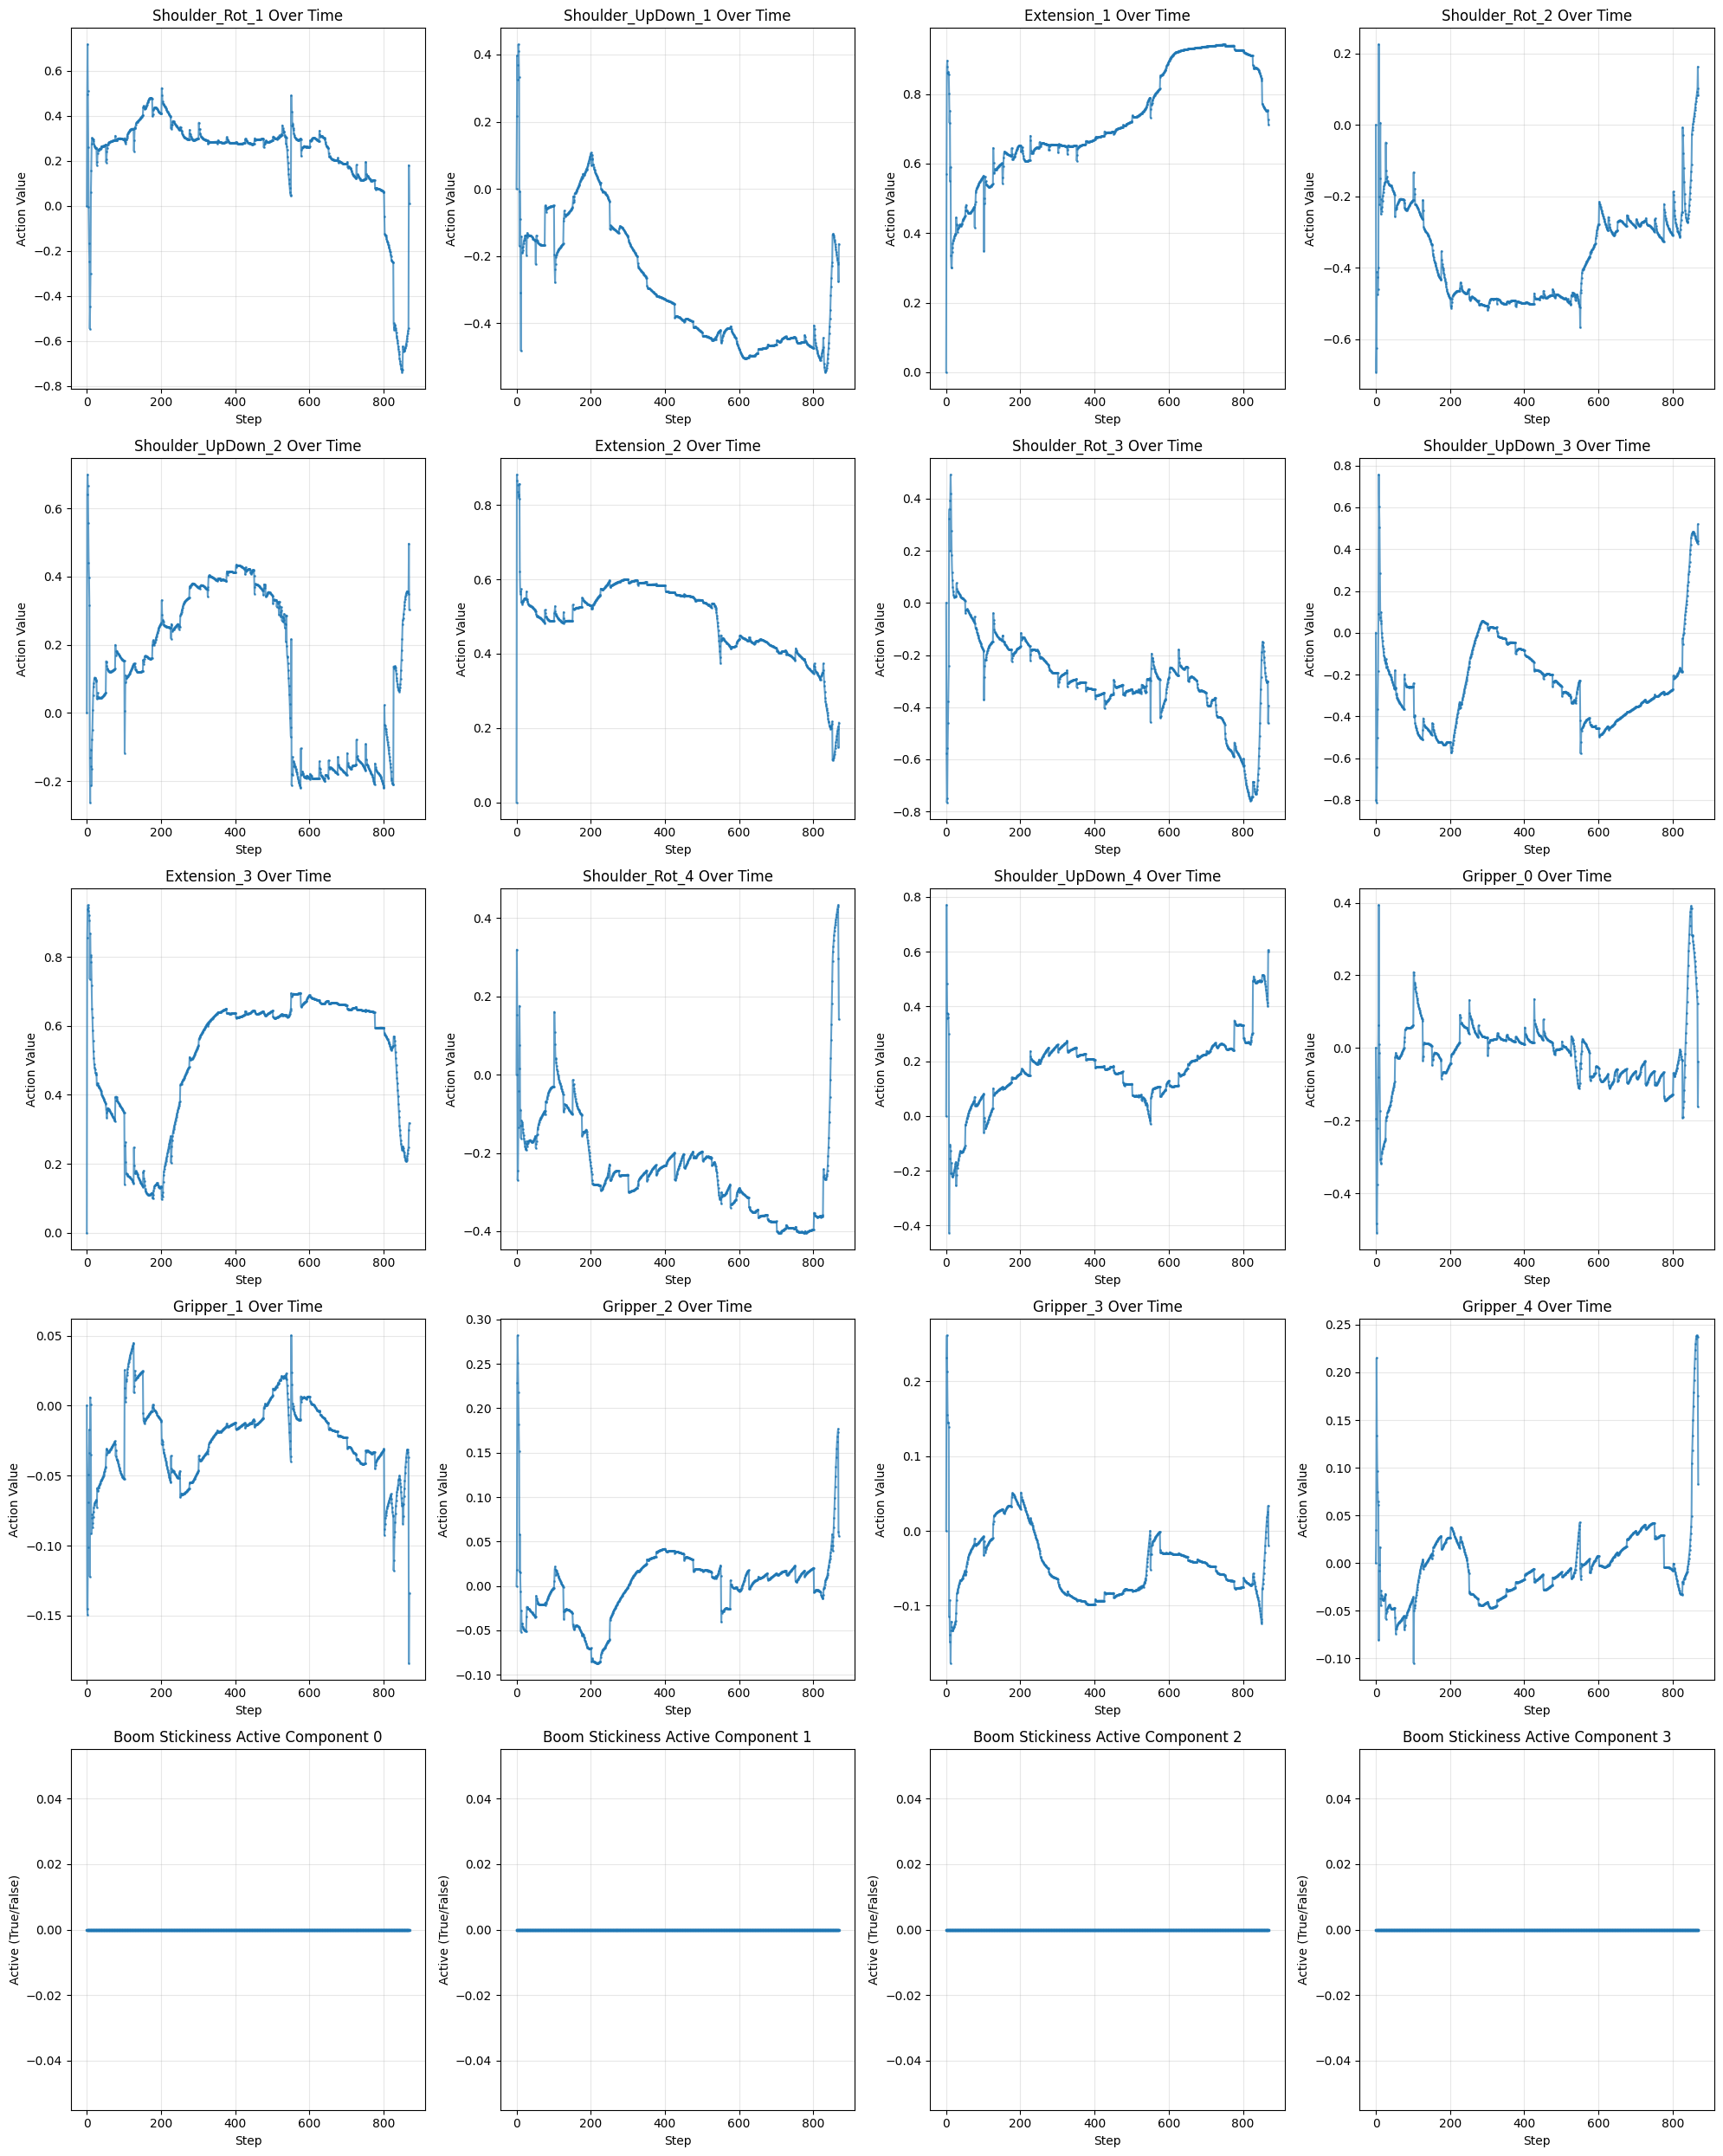

Action Statistics:
--------------------------------------------------
Shoulder_Rot_1 : mean=  0.2205, std=  0.2258, min= -0.7386, max=  0.7179
Shoulder_UpDown_1: mean= -0.2850, std=  0.1875, min= -0.5452, max=  0.4301
Extension_1    : mean=  0.7268, std=  0.1567, min=  0.0000, max=  0.9431
Shoulder_Rot_2 : mean= -0.3585, std=  0.1327, min= -0.6924, max=  0.2259
Shoulder_UpDown_2: mean=  0.1280, std=  0.2307, min= -0.2628, max=  0.6988
Extension_2    : mean=  0.4882, std=  0.1042, min=  0.0000, max=  0.8812
Shoulder_Rot_3 : mean= -0.2905, std=  0.1721, min= -0.7654, max=  0.4917
Shoulder_UpDown_3: mean= -0.2438, std=  0.2164, min= -0.8119, max=  0.7563
Extension_3    : mean=  0.5145, std=  0.1901, min=  0.0000, max=  0.9504
Shoulder_Rot_4 : mean= -0.2311, std=  0.1418, min= -0.4041, max=  0.4336
Shoulder_UpDown_4: mean=  0.1674, std=  0.1342, min= -0.4265, max=  0.7706
Gripper_0      : mean= -0.0153, std=  0.0943, min= -0.5091, max=  0.3937
Gripper_1      : mean= -0.0244, std=  0.0284, 

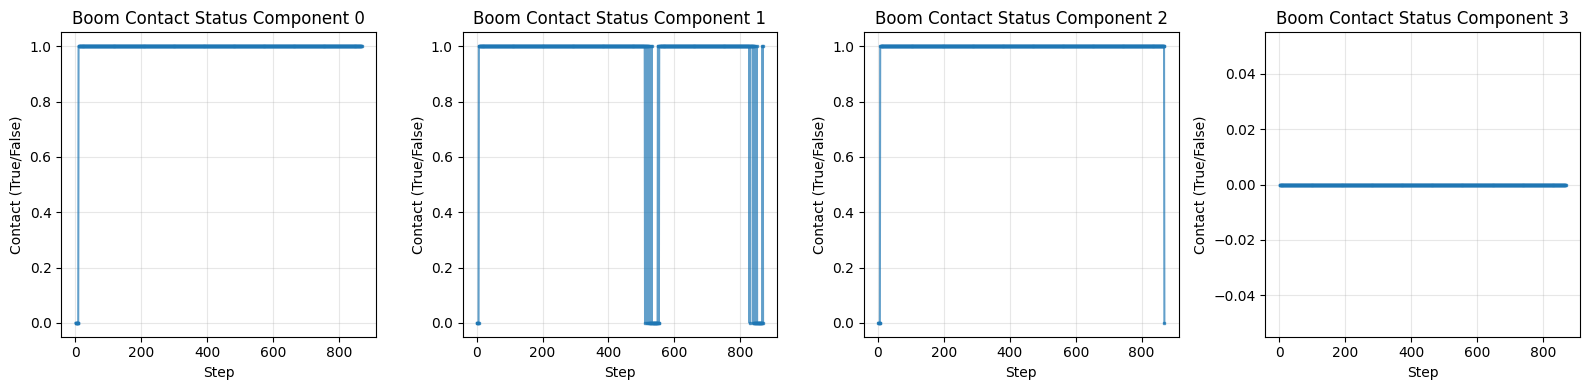


Boom Contact Status Statistics:
--------------------------------------------------
Component  0:  860/ 869 in contact (99.0%)
Component  1:  808/ 869 in contact (93.0%)
Component  2:  862/ 869 in contact (99.2%)
Component  3:    0/ 869 in contact (0.0%)


In [ ]:
# Extract action outputs data
action_data = {}
action_steps = []
boom_stickiness_data = []
boom_stickiness_steps = []
action_names = ["Shoulder_Rot", "Shoulder_UpDown", "Extension"]

for entry in data:
    if 'info' in entry and 'last_act' in entry['info']:
        step = entry['step']
        action_steps.append(step)
        
        actions = entry['info']['last_act']
        for i, action_value in enumerate(actions):
            action_name = f"{action_names[i % 3]}_{i // 3 + 1}"  # Adjust action name to match the expected format
            if i >= 11:  # For gripper actions
                action_name = f'Gripper_{i-11}'
            if action_name not in action_data:
                action_data[action_name] = []
            action_data[action_name].append(action_value)
    
    if 'info' in entry and 'boom_stickiness_active' in entry['info']:
        boom_stickiness_steps.append(entry['step'])
        boom_stickiness_data.append(entry['info']['boom_stickiness_active'])

# Create subplots for all actions
action_names = list(action_data.keys())
num_actions = len(action_names)

# Calculate grid dimensions (including boom stickiness)
total_plots = num_actions + len(boom_stickiness_data[0]) if boom_stickiness_data else num_actions
cols = 4
rows = (total_plots + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
axes = axes.flatten() if total_plots > 1 else [axes]

# Plot each action
plot_idx = 0
for i, action_name in enumerate(action_names):
    axes[plot_idx].plot(action_steps, action_data[action_name], marker='o', markersize=1, alpha=0.7)
    axes[plot_idx].set_title(f'{action_name} Over Time')
    axes[plot_idx].set_xlabel('Step')
    axes[plot_idx].set_ylabel('Action Value')
    axes[plot_idx].grid(True, alpha=0.3)
    plot_idx += 1

# Plot boom stickiness components
if boom_stickiness_data:
    boom_array = np.array(boom_stickiness_data)
    num_boom_components = boom_array.shape[1]
    
    for i in range(num_boom_components):
        axes[plot_idx].plot(boom_stickiness_steps, boom_array[:, i], marker='s', markersize=2, alpha=0.7)
        axes[plot_idx].set_title(f'Boom Stickiness Active Component {i}')
        axes[plot_idx].set_xlabel('Step')
        axes[plot_idx].set_ylabel('Active (True/False)')
        axes[plot_idx].grid(True, alpha=0.3)
        plot_idx += 1

# Hide unused subplots
for i in range(plot_idx, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

# Print statistics
print("Action Statistics:")
print("-" * 50)
for action_name, values in action_data.items():
    values = np.array(values)
    print(f"{action_name:15s}: mean={np.mean(values):8.4f}, std={np.std(values):8.4f}, min={np.min(values):8.4f}, max={np.max(values):8.4f}")

if boom_stickiness_data:
    print("\nBoom Stickiness Statistics:")
    print("-" * 50)
    boom_array = np.array(boom_stickiness_data)
    for i in range(boom_array.shape[1]):
        component_data = boom_array[:, i]
        true_count = np.sum(component_data)
        total_count = len(component_data)
        print(f"Component {i:2d}: {true_count:4d}/{total_count:4d} active ({100*true_count/total_count:.1f}%)")

    

# Overlay plots: Gripper, Boom Stickiness, and Contact Status per Boom

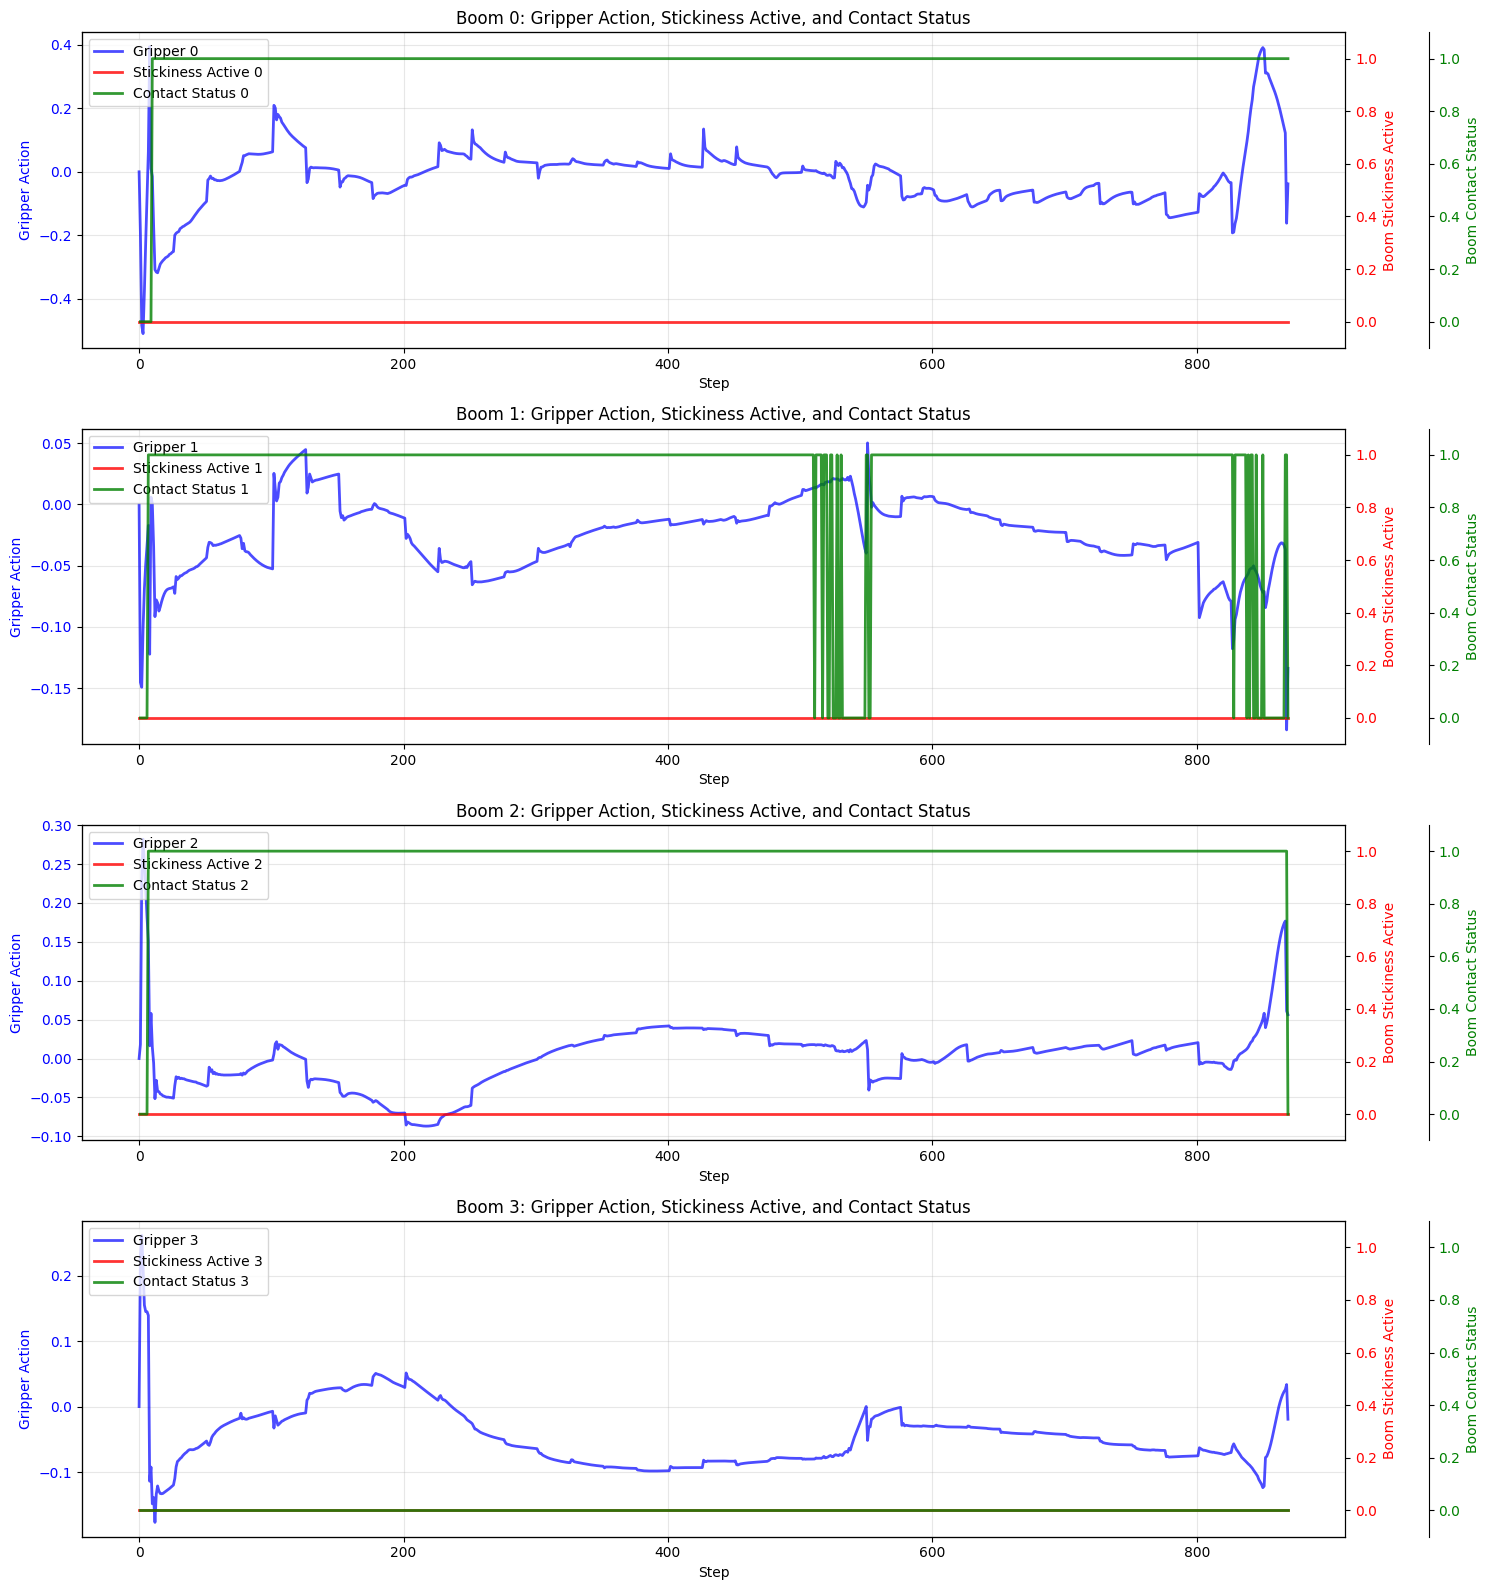

Boom Correlation Analysis:
------------------------------------------------------------

Boom 0:
  Gripper-Stickiness correlation: nan
  Gripper-Contact correlation:    0.153
  Stickiness-Contact correlation: nan
  All three active simultaneously: 0/869 steps (0.0%)
  Stickiness active: 0/869 steps (0.0%)
  Contact active:    860/869 steps (99.0%)

Boom 1:
  Gripper-Stickiness correlation: nan
  Gripper-Contact correlation:    0.045
  Stickiness-Contact correlation: nan
  All three active simultaneously: 0/869 steps (0.0%)
  Stickiness active: 0/869 steps (0.0%)
  Contact active:    808/869 steps (93.0%)

Boom 2:
  Gripper-Stickiness correlation: nan
  Gripper-Contact correlation:    -0.338
  Stickiness-Contact correlation: nan
  All three active simultaneously: 0/869 steps (0.0%)
  Stickiness active: 0/869 steps (0.0%)
  Contact active:    862/869 steps (99.2%)

Boom 3:
  Gripper-Stickiness correlation: nan
  Gripper-Contact correlation:    nan
  Stickiness-Contact correlation: nan
  

/home/ga53voq/.conda/envs/pyenv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3063: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/ga53voq/.conda/envs/pyenv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3064: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [ ]:
# Extract and plot boom_contact_status data
boom_contact_data = []
boom_contact_steps = []

for entry in data:
    if 'info' in entry and 'boom_contact_status' in entry['info']:
        boom_contact_steps.append(entry['step'])
        boom_contact_data.append(entry['info']['boom_contact_status'])
# Create overlay plots for each boom: Gripper + Boom Stickiness + Contact Status

if boom_stickiness_data and boom_contact_data:
    boom_array = np.array(boom_stickiness_data)
    boom_contact_array = np.array(boom_contact_data)
    num_booms = boom_array.shape[1]
    
    # Assume we have the same number of grippers as booms
    gripper_actions = [action_data[f'Gripper_{i}'] for i in range(num_booms) if f'Gripper_{i}' in action_data]
    
    # Create one subplot per boom
    fig, axes = plt.subplots(num_booms, 1, figsize=(15, 4 * num_booms))
    if num_booms == 1:
        axes = [axes]
    
    for boom_idx in range(num_booms):
        ax = axes[boom_idx]
        
        # Create twin axes for different scales
        ax2 = ax.twinx()
        ax3 = ax.twinx()
        
        # Offset the third y-axis
        ax3.spines['right'].set_position(('outward', 60))
        
        # Plot gripper action (continuous values)
        if boom_idx < len(gripper_actions):
            line1 = ax.plot(action_steps, gripper_actions[boom_idx], 'b-', alpha=0.7, linewidth=2, label=f'Gripper {boom_idx}')
            ax.set_ylabel('Gripper Action', color='b')
            ax.tick_params(axis='y', labelcolor='b')
        
        # Plot boom stickiness (boolean)
        line2 = ax2.plot(boom_stickiness_steps, boom_array[:, boom_idx], 'r-', alpha=0.8, linewidth=2, label=f'Stickiness Active {boom_idx}')
        ax2.set_ylabel('Boom Stickiness Active', color='r')
        ax2.tick_params(axis='y', labelcolor='r')
        ax2.set_ylim(-0.1, 1.1)
        
        # Plot boom contact status (boolean)
        line3 = ax3.plot(boom_contact_steps, boom_contact_array[:, boom_idx], 'g-', alpha=0.8, linewidth=2, label=f'Contact Status {boom_idx}')
        ax3.set_ylabel('Boom Contact Status', color='g')
        ax3.tick_params(axis='y', labelcolor='g')
        ax3.set_ylim(-0.1, 1.1)
        
        # Set title and labels
        ax.set_title(f'Boom {boom_idx}: Gripper Action, Stickiness Active, and Contact Status')
        ax.set_xlabel('Step')
        ax.grid(True, alpha=0.3)
        
        # Create combined legend
        lines1 = line1 if boom_idx < len(gripper_actions) else []
        lines = lines1 + line2 + line3
        labels = [l.get_label() for l in lines]
        ax.legend(lines, labels, loc='upper left')
    
    plt.tight_layout()
    plt.show()
    
    # Print correlation analysis
    print("Boom Correlation Analysis:")
    print("-" * 60)
    for boom_idx in range(num_booms):
        print(f"\nBoom {boom_idx}:")
        
        # Get synchronized data (ensure all arrays have same length)
        min_len = min(len(boom_stickiness_steps), len(boom_contact_steps))
        if boom_idx < len(gripper_actions):
            min_len = min(min_len, len(action_steps))
            
        stickiness_sync = boom_array[:min_len, boom_idx]
        contact_sync = boom_contact_array[:min_len, boom_idx]
        
        if boom_idx < len(gripper_actions):
            gripper_sync = np.array(gripper_actions[boom_idx][:min_len])
            
            # Calculate correlations
            stickiness_contact_corr = np.corrcoef(stickiness_sync, contact_sync)[0, 1]
            gripper_stickiness_corr = np.corrcoef(gripper_sync, stickiness_sync)[0, 1]
            gripper_contact_corr = np.corrcoef(gripper_sync, contact_sync)[0, 1]
            
            print(f"  Gripper-Stickiness correlation: {gripper_stickiness_corr:.3f}")
            print(f"  Gripper-Contact correlation:    {gripper_contact_corr:.3f}")
            print(f"  Stickiness-Contact correlation: {stickiness_contact_corr:.3f}")
            
            # Calculate when all three are active/high
            high_gripper = gripper_sync > np.mean(gripper_sync)
            all_active = high_gripper & stickiness_sync.astype(bool) & contact_sync.astype(bool)
            all_active_pct = 100 * np.sum(all_active) / len(all_active)
            print(f"  All three active simultaneously: {np.sum(all_active)}/{len(all_active)} steps ({all_active_pct:.1f}%)")
        else:
            stickiness_contact_corr = np.corrcoef(stickiness_sync, contact_sync)[0, 1]
            print(f"  Stickiness-Contact correlation: {stickiness_contact_corr:.3f}")
            
        # Individual statistics
        stickiness_active_pct = 100 * np.sum(stickiness_sync) / len(stickiness_sync)
        contact_active_pct = 100 * np.sum(contact_sync) / len(contact_sync)
        print(f"  Stickiness active: {np.sum(stickiness_sync)}/{len(stickiness_sync)} steps ({stickiness_active_pct:.1f}%)")
        print(f"  Contact active:    {np.sum(contact_sync)}/{len(contact_sync)} steps ({contact_active_pct:.1f}%)")

else:
    print("Cannot create overlay plots: Missing boom stickiness or contact data")

# Contact analysis